Develop a program to create histograms for all numerical features and analyze the distribution of each feature. Generate box plots for all numerical features and identify any outliers. Use California Housing dataset.

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.datasets import fetch_california_housing

In [17]:
housing_df = fetch_california_housing(as_frame=True).frame
numerical_features = housing_df.select_dtypes(include=[np.number]).columns

In [18]:
def plot(plot_type, title_prefix, **kwargs):
    plt.figure(figsize=(15, 10))

    for i, feature in enumerate(numerical_features, start=1):
        plt.subplot(3, 3, i)
        plot_type(housing_df, x=feature, **kwargs)
        plt.title(f"{title_prefix} {feature}")

    plt.tight_layout()
    plt.show()

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

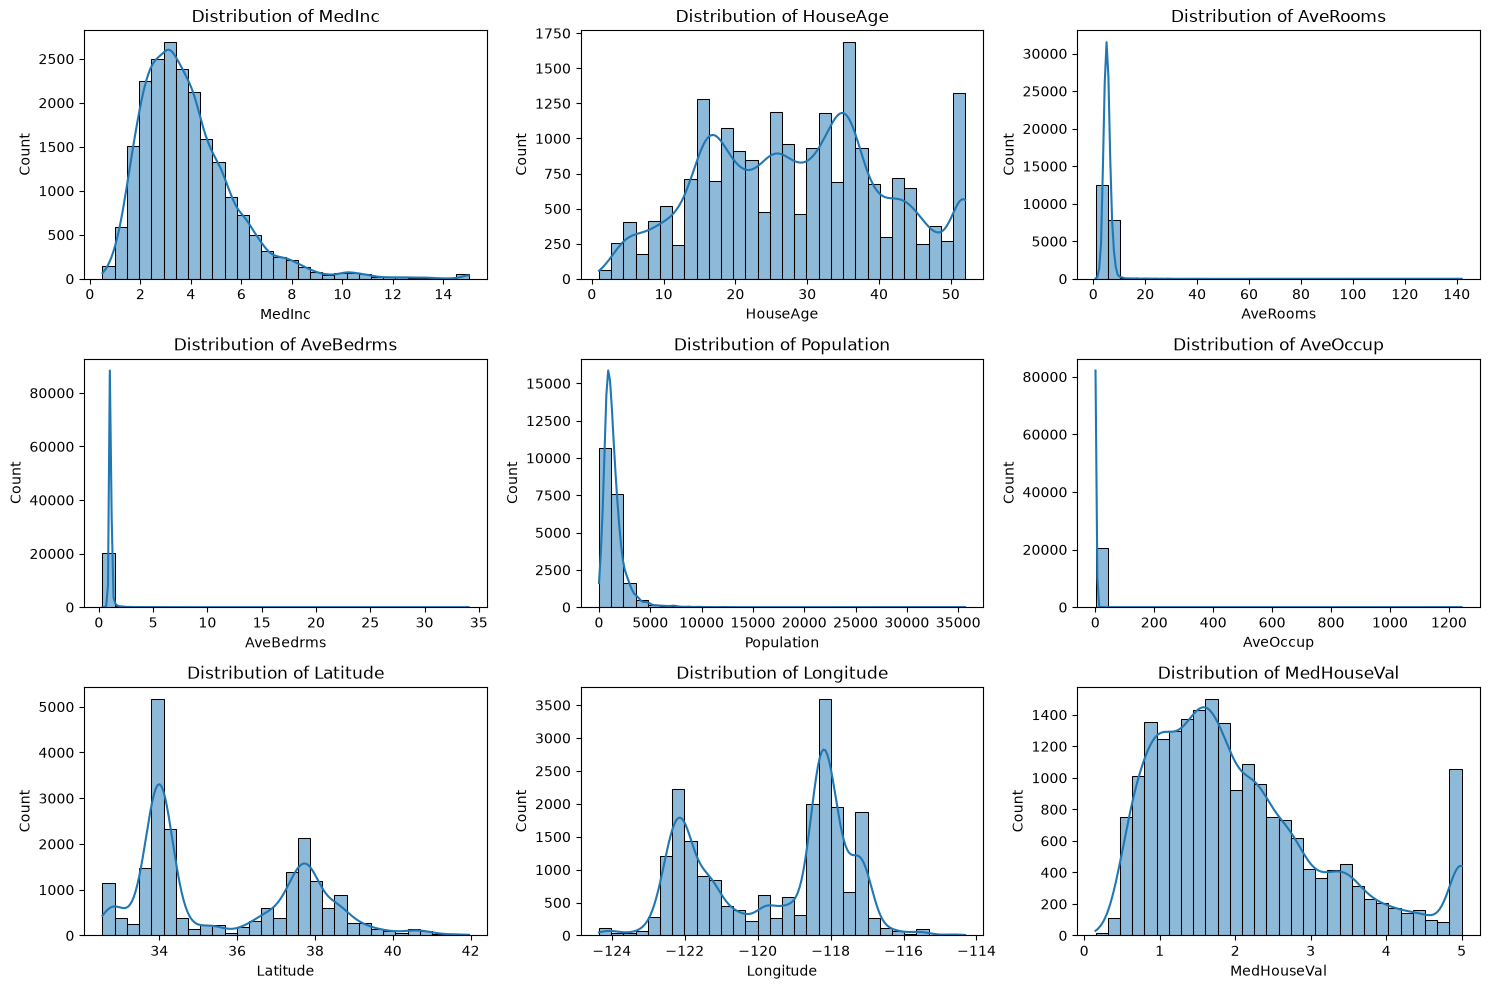

In [19]:
print(housing_df.describe())
plot(sns.histplot, "Distribution of", kde=True, bins=30)

MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVal: 1071 outliers


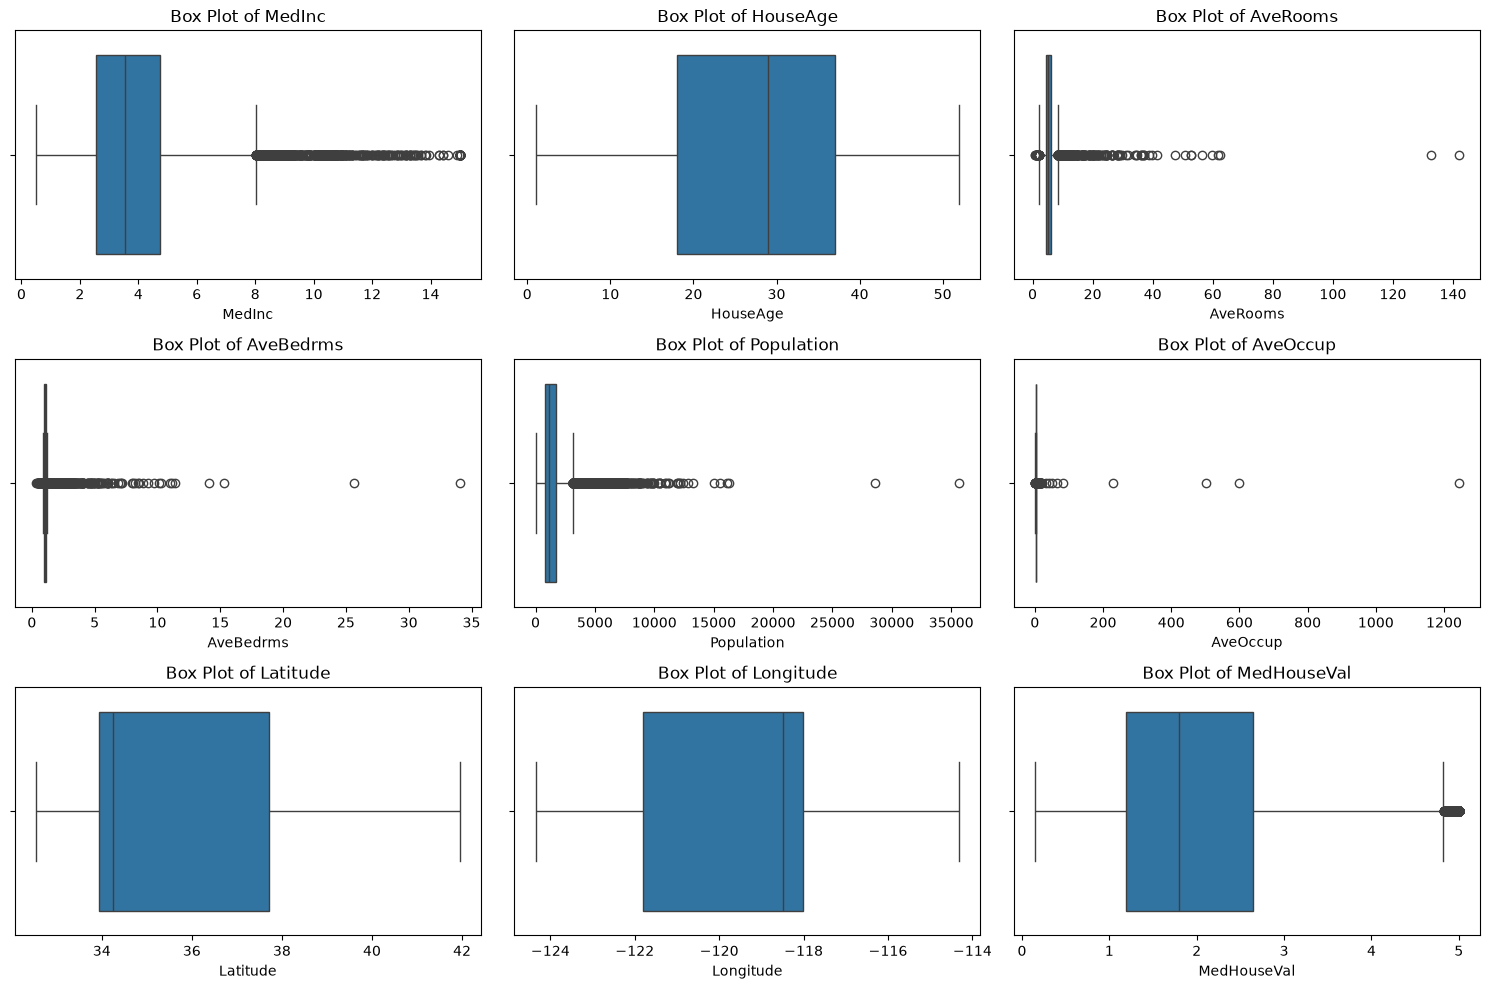

In [20]:
for feature in numerical_features:
    series = housing_df[feature]

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    print(f"{feature}: {outliers} outliers")

plot(sns.boxplot, "Box Plot of")